# CNN Model with made up data

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import pandas as pd

In [2]:
df = pd.DataFrame({
    "soil_moisture" : [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60, 0.18, 0.45, 0.80],
    "temperature_c" : [34, 30, 26, 22, 28, 30, 19, 22, 25, 33, 12, 21],
    "sunlght_hours" : [9, 8, 7, 4, 8, 10, 12, 5, 9, 11, 3, 9],
    "needs_water" : [1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0],
})
df

,soil_moisture,temperature_c,sunlght_hours,needs_water
0,0.10,34,9,1
1,0.15,30,8,1
2,0.20,26,7,1
3,0.25,22,4,1
4,0.30,28,8,0
5,0.35,30,10,0
6,0.40,19,12,0
7,0.50,22,5,0
8,0.60,25,9,1
9,0.18,33,11,0


In [3]:
df.columns

Index(['soil_moisture', 'temperature_c', 'sunlght_hours', 'needs_water'], dtype='str')

In [4]:
X = df[['soil_moisture', 'temperature_c', 'sunlght_hours']]
y = df['needs_water']

In [5]:
X_min = X.min()
X_max = X.max()

In [6]:
# mean median mode is used for scaling the values we have took for making the values continuous
X_scaled = ( X - X_min ) / ( X_max - X_min + 1e-8 )
X_scaled

,soil_moisture,temperature_c,sunlght_hours
0,0.000000,1.000000,0.666667
1,0.071429,0.818182,0.555556
2,0.142857,0.636364,0.444444
3,0.214286,0.454545,0.111111
4,0.285714,0.727273,0.555556
5,0.357143,0.818182,0.777778
6,0.428571,0.318182,1.000000
7,0.571429,0.454545,0.222222
8,0.714286,0.590909,0.666667
9,0.114286,0.954545,0.888889


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
model = keras.Sequential(
    [
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(8, activation='relu'),         # 8 are input layer relu prevents from making our values too large or too strong
        layers.Dense(1, activation='sigmoid'),      # sigmoid because it will give us proper output
    ]
)  # Sequential is a model for ANN (used in every DL model)

In [9]:
model.compile(optimizer="adam", loss='binary_crossentropy', metrics=['accuracy'])

---
### DL Model 

First we take ```history_full``` with large batch size then we take ```history``` with 1 as batch size then we take ```history_mb``` with less that ```history_full``` batch size

---

In [10]:
history_full = model.fit(X_train, y_train.values.reshape(-1, 1), epochs=100, batch_size=50, verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 828ms/step - accuracy: 0.5556 - loss: 0.7546
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5556 - loss: 0.7536
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5556 - loss: 0.7525
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5556 - loss: 0.7515
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5556 - loss: 0.7505
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5556 - loss: 0.7495
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5556 - loss: 0.7485
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5556 - loss: 0.7475
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5556 - loss: 0.7466
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5556 - loss: 0.7456
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5556 - loss: 0.7447
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5556 - l

In [11]:
history = model.fit(
    X_train.values, y_train.values.reshape(-1, 1),
    validation_data = (X_test.values, y_test.values),
    epochs = 100,
    batch_size = 1,             # whole bunch of data will be taken without any further division from the history_full layer
    verbose = 1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5556 - loss: 0.6934 - val_accuracy: 0.3333 - val_loss: 0.7346
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5556 - loss: 0.6890 - val_accuracy: 0.3333 - val_loss: 0.7316
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6667 - loss: 0.6855 - val_accuracy: 0.3333 - val_loss: 0.7307
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6667 - loss: 0.6835 - val_accuracy: 0.3333 - val_loss: 0.7322
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6667 - loss: 0.6810 - val_accuracy: 0.3333 - val_loss: 0.7318
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6667 - loss: 0.6792 - val_accuracy: 0.3333 - val_loss: 0.7331
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6667 - loss: 0.6774 - val_accuracy: 0.0000e+00 - val_loss: 0.7333
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6667 - loss: 0.6773 - val_accuracy: 0.0000e+00 - val_

In [12]:
history_mb = model.fit(X_train, y_train.values.reshape(-1, 1), epochs=100, batch_size=20, verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8889 - loss: 0.5596
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8889 - loss: 0.5595
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8889 - loss: 0.5593
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8889 - loss: 0.5591
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8889 - loss: 0.5590
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8889 - loss: 0.5588
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8889 - loss: 0.5586
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8889 - loss: 0.5585
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8889 - loss: 0.5583
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8889 - loss: 0.5581
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8889 - loss: 0.5580
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8889 - lo

In [13]:
from tensorflow.keras import optimizers

In [16]:
opt = optimizers.SGD(learning_rate=0.01, momentum=0.9)  # Stochastic Gradient Descent, momentum = remember the previous values
opt 

In [18]:
print(f"keras.src.optimizers.sgd.SGD at {0x2167d681e10}")

keras.src.optimizers.sgd.SGD at 2295616511504


In [19]:
import matplotlib.pyplot as plt

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


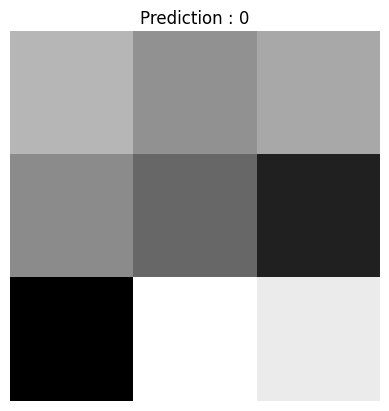

In [26]:
prediction = model.predict(X_test)
plt.imshow(X_test, cmap='gray')         # all gray points in the plot are 0 therefore prediction is 0
plt.title(f"Prediction : {prediction[1].argmax()}")
plt.axis('off')
plt.show()

# CNN Model with proper data

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import optimizers
import matplotlib.pyplot as plt

In [33]:
df = tf.keras.datasets.mnist.load_data